In [2]:
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_identity = pd.read_csv("../data/train_identity.csv")
df_transaction = pd.read_csv("../data/train_transaction.csv")

In [4]:
df_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## Dataset Overview

We can see that the columns are anonymized. Here is the snippet from description:

> **Variables in this table are identity information** – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta's fraud protection system and digital security partners. 
> 
> *(The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)*

---

### **Categorical Features:** 
- DeviceType
- DeviceInfo  
- id_12 - id_38

---

### **Important Observation:**
**Observation:** Missing values are prevalent throughout the identity features.

Columns with missing values: 38

Top 15 columns with most missing values:
Column  Missing Count  Missing Percentage
 id_24         139486           96.708798
 id_25         139101           96.441868
 id_07         139078           96.425922
 id_08         139078           96.425922
 id_21         139074           96.423149
 id_26         139070           96.420375
 id_23         139064           96.416215
 id_27         139064           96.416215
 id_22         139064           96.416215
 id_18          99120           68.722137
 id_03          77909           54.016071
 id_04          77909           54.016071
 id_33          70944           49.187079
 id_09          69307           48.052110
 id_10          69307           48.052110


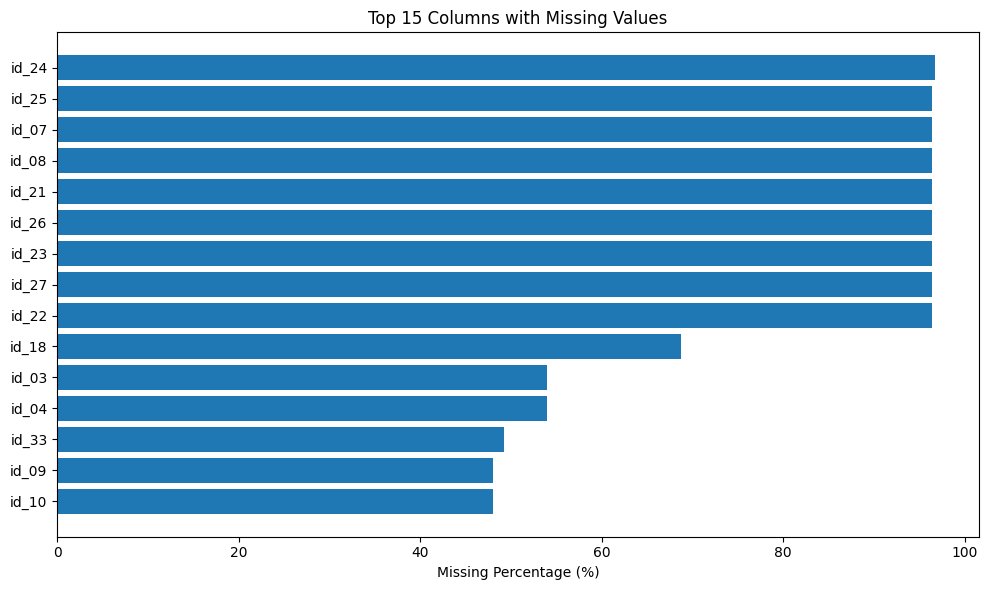

In [7]:
# Missing values analysis
missing_counts = df_identity.isnull().sum()
missing_percentages = (df_identity.isnull().sum() / len(df_identity)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percentages.values
}).sort_values('Missing Percentage', ascending=False)

# Show columns with missing values
print(f"Columns with missing values: {len(missing_df[missing_df['Missing Count'] > 0])}")
print(f"\nTop 15 columns with most missing values:")
print(missing_df[missing_df['Missing Count'] > 0].head(15).to_string(index=False))



top_missing = missing_df[missing_df['Missing Count'] > 0].head(15)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_missing)), top_missing['Missing Percentage'])
plt.yticks(range(len(top_missing)), top_missing['Column'])
plt.xlabel('Missing Percentage (%)')
plt.title('Top 15 Columns with Missing Values')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Let's merge identity and transaction tables and find out what percentage of transaction have associated identity

Transaction records: 590,540
Identity records: 144,233

--- Identity Coverage Analysis ---
Transactions WITH identity data: 144,233 (24.42%)
Transactions WITHOUT identity data: 446,307 (75.58%)


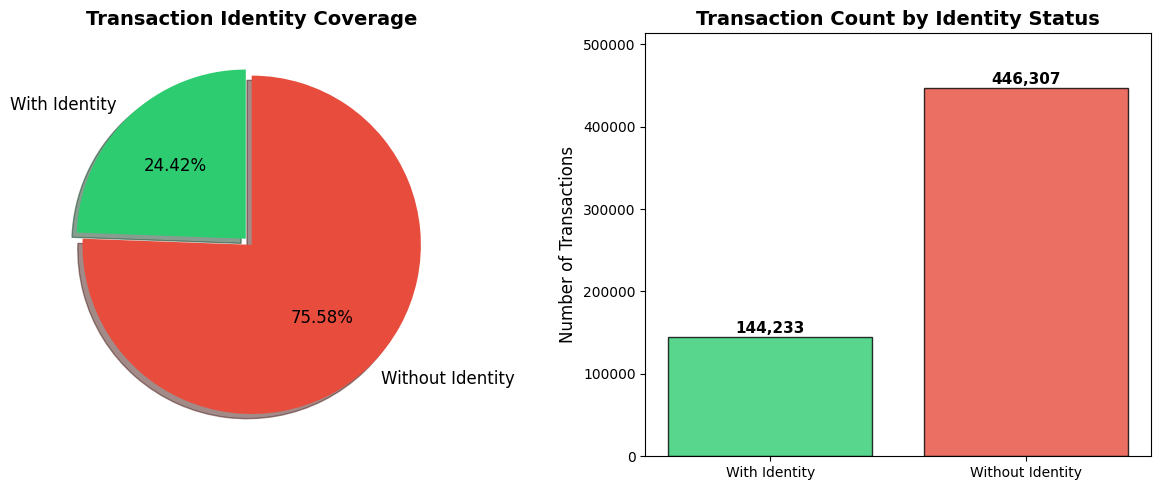

In [6]:


print(f"Transaction records: {len(df_transaction):,}")
print(f"Identity records: {len(df_identity):,}")

# Merge on TransactionID
merged = df_transaction.merge(df_identity, on='TransactionID', how='left', indicator=True)

# Calculate percentage with identity data
has_identity = (merged['_merge'] == 'both').sum()
no_identity = (merged['_merge'] == 'left_only').sum()

print(f"\n--- Identity Coverage Analysis ---")
print(f"Transactions WITH identity data: {has_identity:,} ({has_identity / len(merged) * 100:.2f}%)")
print(f"Transactions WITHOUT identity data: {no_identity:,} ({no_identity / len(merged) * 100:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels = ['With Identity', 'Without Identity']
sizes = [has_identity, no_identity]
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Transaction Identity Coverage', fontsize=14, fontweight='bold')

# Bar chart 
axes[1].bar(['With Identity', 'Without Identity'], sizes, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Number of Transactions', fontsize=12)
axes[1].set_title('Transaction Count by Identity Status', fontsize=14, fontweight='bold')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, max(sizes) * 1.15)

plt.tight_layout()
plt.show()


Now let's take a look at the deanonimyzed categorical features

In [ ]:
# DeviceType and DeviceInfo Overview
print("=== DeviceType & DeviceInfo Overview ===\n")

print(f"DeviceType: {df_identity['DeviceType'].nunique()} unique values | {df_identity['DeviceType'].isnull().sum() / len(df_identity) * 100:.2f}% missing")
print(f"DeviceInfo: {df_identity['DeviceInfo'].nunique()} unique values | {df_identity['DeviceInfo'].isnull().sum() / len(df_identity) * 100:.2f}% missing")

print("\n--- DeviceType Value Counts ---")
print(df_identity['DeviceType'].value_counts())

print("\n--- Top 15 DeviceInfo Values ---")
print(df_identity['DeviceInfo'].value_counts().head(15))


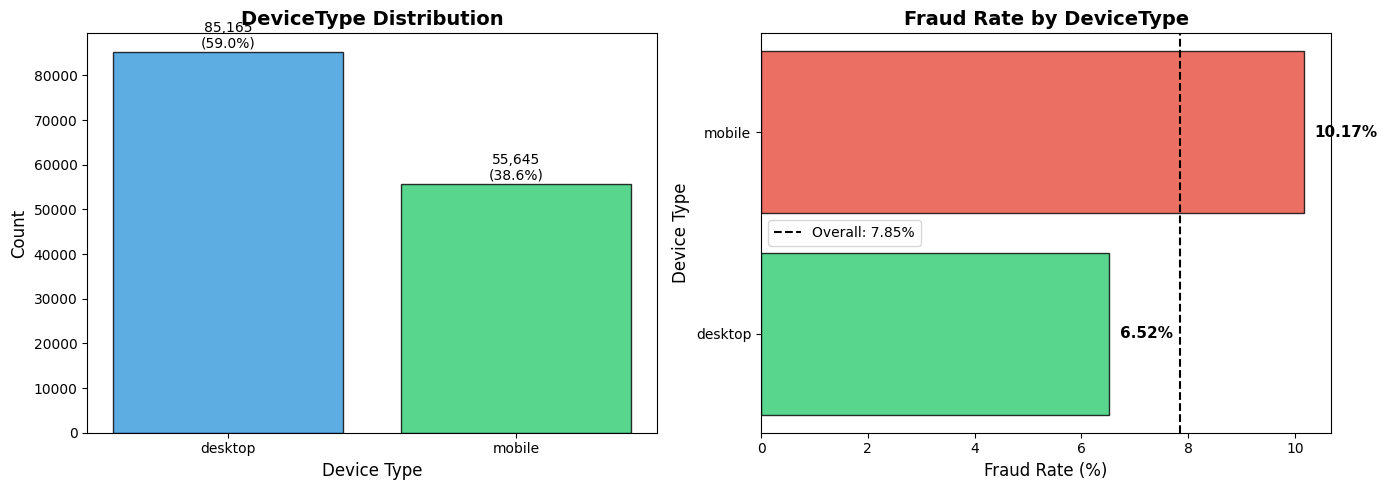


DeviceType Fraud Statistics:
             sum  count  fraud_rate
DeviceType                         
desktop     5554  85165    6.521458
mobile      5657  55645   10.166232


In [8]:
# DeviceType Analysis with Fraud Rate
# First merge identity with transaction to get isFraud column
identity_with_fraud = df_identity.merge(df_transaction[['TransactionID', 'isFraud']], on='TransactionID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DeviceType distribution
device_type_counts = identity_with_fraud['DeviceType'].value_counts()
colors_dist = ['#3498db', '#2ecc71']
axes[0].bar(device_type_counts.index, device_type_counts.values, color=colors_dist, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Device Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('DeviceType Distribution', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(device_type_counts.items()):
    axes[0].text(i, val + 1000, f'{val:,}\n({val/len(identity_with_fraud)*100:.1f}%)', ha='center', fontsize=10)

# Fraud rate by DeviceType
device_fraud = identity_with_fraud.groupby('DeviceType')['isFraud'].agg(['sum', 'count'])
device_fraud['fraud_rate'] = device_fraud['sum'] / device_fraud['count'] * 100
device_fraud = device_fraud.sort_values('fraud_rate', ascending=True)

colors_fraud = ['#2ecc71', '#e74c3c']
axes[1].barh(device_fraud.index, device_fraud['fraud_rate'], color=colors_fraud, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Fraud Rate (%)', fontsize=12)
axes[1].set_ylabel('Device Type', fontsize=12)
axes[1].set_title('Fraud Rate by DeviceType', fontsize=14, fontweight='bold')
axes[1].axvline(x=identity_with_fraud['isFraud'].mean() * 100, color='black', linestyle='--', 
                label=f'Overall: {identity_with_fraud["isFraud"].mean()*100:.2f}%')
for i, (idx, row) in enumerate(device_fraud.iterrows()):
    axes[1].text(row['fraud_rate'] + 0.2, i, f"{row['fraud_rate']:.2f}%", va='center', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nDeviceType Fraud Statistics:")
print(device_fraud.to_string())


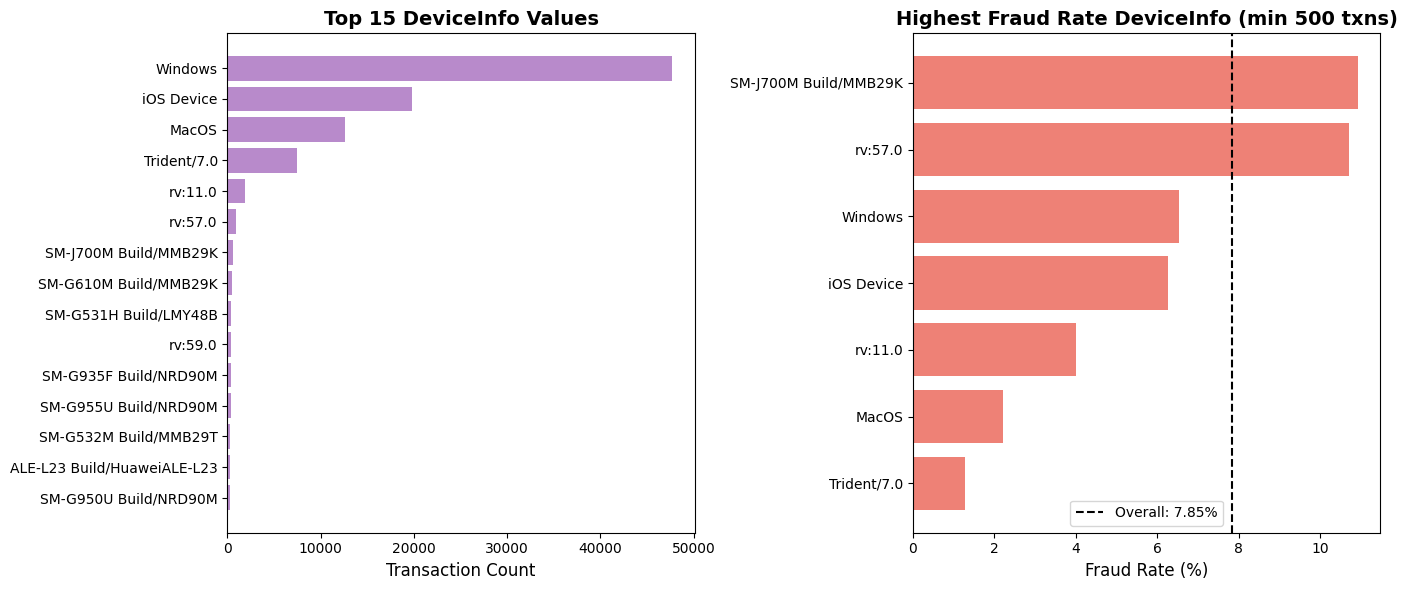

Top 15 High-Risk DeviceInfo (min 500 transactions):
                       Total Txns  Fraud Count  Fraud Rate (%)
DeviceInfo                                                    
SM-J700M Build/MMB29K         549           60       10.928962
rv:57.0                       962          103       10.706861
Windows                     47722         3121        6.539961
iOS Device                  19782         1240        6.268325
rv:11.0                      1901           76        3.997896
MacOS                       12573          278        2.211087
Trident/7.0                  7440           96        1.290323


In [9]:
# DeviceInfo Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 DeviceInfo by count
device_info_counts = identity_with_fraud['DeviceInfo'].value_counts().head(15)
axes[0].barh(range(len(device_info_counts)), device_info_counts.values, color='#9b59b6', alpha=0.7)
axes[0].set_yticks(range(len(device_info_counts)))
axes[0].set_yticklabels(device_info_counts.index)
axes[0].set_xlabel('Transaction Count', fontsize=12)
axes[0].set_title('Top 15 DeviceInfo Values', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Fraud rate for top DeviceInfo values (min 500 transactions)
device_info_fraud = identity_with_fraud.groupby('DeviceInfo')['isFraud'].agg(['sum', 'count'])
device_info_fraud['fraud_rate'] = device_info_fraud['sum'] / device_info_fraud['count'] * 100
device_info_fraud_filtered = device_info_fraud[device_info_fraud['count'] >= 500].sort_values('fraud_rate', ascending=False).head(15)

axes[1].barh(range(len(device_info_fraud_filtered)), device_info_fraud_filtered['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[1].set_yticks(range(len(device_info_fraud_filtered)))
axes[1].set_yticklabels(device_info_fraud_filtered.index)
axes[1].set_xlabel('Fraud Rate (%)', fontsize=12)
axes[1].set_title('Highest Fraud Rate DeviceInfo (min 500 txns)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].axvline(x=identity_with_fraud['isFraud'].mean() * 100, color='black', linestyle='--', 
                label=f'Overall: {identity_with_fraud["isFraud"].mean()*100:.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show the statistics
print("Top 15 High-Risk DeviceInfo (min 500 transactions):")
print(device_info_fraud_filtered[['count', 'sum', 'fraud_rate']].rename(
    columns={'count': 'Total Txns', 'sum': 'Fraud Count', 'fraud_rate': 'Fraud Rate (%)'}).to_string())


In [ ]:
# Extract OS/Platform patterns from DeviceInfo
def extract_platform(device_info):
    if pd.isna(device_info):
        return 'Unknown'
    device_info = str(device_info).lower()
    if 'windows' in device_info:
        return 'Windows'
    elif 'ios' in device_info or 'iphone' in device_info or 'ipad' in device_info:
        return 'iOS'
    elif 'mac' in device_info:
        return 'MacOS'
    elif 'android' in device_info or 'samsung' in device_info or 'lg' in device_info or 'huawei' in device_info:
        return 'Android'
    elif 'linux' in device_info:
        return 'Linux'
    else:
        return 'Other'

identity_with_fraud['Platform'] = identity_with_fraud['DeviceInfo'].apply(extract_platform)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Platform distribution
platform_counts = identity_with_fraud['Platform'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
axes[0].bar(platform_counts.index, platform_counts.values, color=colors[:len(platform_counts)], edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Platform', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Platform Distribution (extracted from DeviceInfo)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(platform_counts.items()):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontsize=9)

# Fraud rate by Platform
platform_fraud = identity_with_fraud.groupby('Platform')['isFraud'].agg(['sum', 'count'])
platform_fraud['fraud_rate'] = platform_fraud['sum'] / platform_fraud['count'] * 100
platform_fraud = platform_fraud.sort_values('fraud_rate', ascending=True)

axes[1].barh(platform_fraud.index, platform_fraud['fraud_rate'], color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Fraud Rate (%)', fontsize=12)
axes[1].set_ylabel('Platform', fontsize=12)
axes[1].set_title('Fraud Rate by Platform', fontsize=14, fontweight='bold')
axes[1].axvline(x=identity_with_fraud['isFraud'].mean() * 100, color='black', linestyle='--',
                label=f'Overall: {identity_with_fraud["isFraud"].mean()*100:.2f}%')
for i, (idx, row) in enumerate(platform_fraud.iterrows()):
    axes[1].text(row['fraud_rate'] + 0.1, i, f"{row['fraud_rate']:.2f}%", va='center', fontsize=10, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nPlatform Fraud Statistics:")
print(platform_fraud.to_string())
